In [1]:
path = r"C:\Users\aksel\.ethograph\example_data\Moll2025\.ethograph\alignment.nwb"

from pynwb import NWBHDF5IO

io = NWBHDF5IO(path, 'r')
nwbfile = io.read()
nwbfile

Data type,uint8
Shape,"(0, 0, 0)"
Array size,0.00 bytes
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),0
Compressed size (bytes),0
Compression ratio,undefined
Data type,object
Shape,"(2,)"


In [2]:
path = r"C:\Users\aksel\.ethograph\example_data\Lockbox\lockbox.nc"

import ethograph as eto

dt = eto.open(path)
dt

<xarray.DataTree>
Group: /
├── Group: /2021-02-15_07-32-44_segment1
│       Dimensions:                           (time: 600, space: 2, keypoints: 13,
│                                              individuals: 1)
│       Coordinates:
│         * time                              (time) float64 5kB 0.0 0.03333 ... 19.97
│         * space                             (space) <U1 8B 'x' 'y'
│         * keypoints                         (keypoints) <U15 780B 'nose' ... 'slidi...
│         * individuals                       (individuals) <U12 48B 'individual_0'
│       Data variables:
│           position                          (time, space, keypoints, individuals) float64 125kB ...
│           confidence                        (time, keypoints, individuals) float64 62kB ...
│           front_velocity                    (time, space, keypoints, individuals) float64 125kB ...
│           front_speed                       (time, keypoints, individuals) float64 62kB ...
│           topview_distance_head_lever_tip   (time, individuals) float64 5kB ...
│           topview_distance_head_stick_head  (time, individuals) float64 5kB ...
│           topview_distance_head_ball        (time, individuals) float64 5kB ...
│       Attributes:
│           source_software:  DeepLabCut
│           ds_type:          poses
│           fps:              30.0
│           time_unit:        seconds
│           trial:            2021-02-15_07-32-44_segment1
├── Group: /2021-05-31_07-34-21_segment2
│       Dimensions:                           (time: 720, space: 2, keypoints: 13,
│                                              individuals: 1)
│       Coordinates:
│         * time                              (time) float64 6kB 0.0 0.03333 ... 23.97
│         * space                             (space) <U1 8B 'x' 'y'
│         * keypoints                         (keypoints) <U15 780B 'nose' ... 'slidi...
│         * individuals                       (individuals) <U12 48B 'individual_0'
│       Data variables:
│           position                          (time, space, keypoints, individuals) float64 150kB ...
│           confidence                        (time, keypoints, individuals) float64 75kB ...
│           front_velocity                    (time, space, keypoints, individuals) float64 150kB ...
│           front_speed                       (time, keypoints, individuals) float64 75kB ...
│           topview_distance_head_lever_tip   (time, individuals) float64 6kB ...
│           topview_distance_head_stick_head  (time, individuals) float64 6kB ...
│           topview_distance_head_ball        (time, individuals) float64 6kB ...
│       Attributes:
│           source_software:  DeepLabCut
│           ds_type:          poses
│           fps:              30.0
│           time_unit:        seconds
│           trial:            2021-05-31_07-34-21_segment2
├── Group: /2021-05-31_07-34-21_segment3
│       Dimensions:                           (time: 750, space: 2, keypoints: 13,
│                                              individuals: 1)
│       Coordinates:
│         * time                              (time) float64 6kB 0.0 0.03333 ... 24.97
│         * space                             (space) <U1 8B 'x' 'y'
│         * keypoints                         (keypoints) <U15 780B 'nose' ... 'slidi...
│         * individuals                       (individuals) <U12 48B 'individual_0'
│       Data variables:
│           position                          (time, space, keypoints, individuals) float64 156kB ...
│           confidence                        (time, keypoints, individuals) float64 78kB ...
│           front_velocity                    (time, space, keypoints, individuals) float64 156kB ...
│           front_speed                       (time, keypoints, individuals) float64 78kB ...
│           topview_distance_head_lever_tip   (time, individuals) float64 6kB ...
│           topview_distance_head_stick_head  (time, individuals) float64 6kB ...


In [8]:
dt.itrial(0).time

<xarray.DataArray 'time' (time: 600)> Size: 5kB
0.0 0.03333 0.06667 0.1 0.1333 0.1667 0.2 ... 19.8 19.83 19.87 19.9 19.93 19.97
Coordinates:
  * time     (time) float64 5kB 0.0 0.03333 0.06667 0.1 ... 19.9 19.93 19.97

In [7]:
from pathlib import Path
from ethograph.crowlab.legacy import convert_session_to_nwb
root = Path(r"C:\Users\aksel\Desktop")
nc_paths = sorted(root.rglob("*.nc"))
import ethograph as eto
print(f"Found {len(nc_paths)} .nc files:")
for p in nc_paths:
    dt = eto.open(p)
    try: 
        nwb = convert_session_to_nwb(dt)
    except Exception as e:
        print(f"Error converting {p}: {e}")
    nwb

Found 79 .nc files:
Error converting C:\Users\aksel\Desktop\ephys\Ivy_250309_111721\ab.nc: TrialTree has no legacy session node to convert.
Error converting C:\Users\aksel\Desktop\ephys\Ivy_250309_111721\xx.nc: TrialTree has no legacy session node to convert.
Error converting C:\Users\aksel\Desktop\ephys\Ivy_250309_111721\yy.nc: TrialTree has no legacy session node to convert.
Error converting C:\Users\aksel\Desktop\ephys\labels\xx_labels_20260215_201856.nc: TrialTree has no legacy session node to convert.
Error converting C:\Users\aksel\Desktop\ephys\labels\xxx_labels_20260218_220811.nc: TrialTree has no legacy session node to convert.
Error converting C:\Users\aksel\Desktop\ephys\y.nc: TrialTree has no legacy session node to convert.
Error converting C:\Users\aksel\Desktop\ethograph_demos\birdpark\copExpBP08_trim.nc: TrialTree has no legacy session node to convert.
Error converting C:\Users\aksel\Desktop\ethograph_demos\Moll2025\labels\Trial_data_labels_20260211_171720.nc: TrialTree 

KeyboardInterrupt: 

In [ ]:
from pynwb import NWBHDF5IO

with NWBHDF5IO(str(nwb), "r") as io:
    nwb_file = io.read()
nwb_file

In [ ]:
nwb_file

In [ ]:
from ethograph.crowlab.legacy import trees_to_df

path = r"C:\Users\aksel\.ethograph\example_data\Moll2025\Trial_data.nc"

import ethograph as eto

dt = eto.open(path)

df = trees_to_df(dt, keep_attrs=[])
df.to_csv(r"C:\Users\aksel\.ethograph\example_data\Moll2025\Trial_data_labels.tsv", index=False, sep="\t")



In [30]:
tsgroup.items()

NameError: name 'tsgroup' is not defined

In [10]:
# we'll import the packages we're going to use
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pynapple as nap
import seaborn as sns
from scipy.signal import correlate2d
from scipy.ndimage import (
    maximum_filter,
    label,
    center_of_mass,
    rotate,
    gaussian_filter,
)
import xarray as xr
from pathlib import Path
from pynwb import NWBHDF5IO

from dandi.dandiapi import DandiAPIClient
import fsspec
from fsspec.implementations.cached import CachingFileSystem
import h5py

# some configuration, you can ignore this
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.5, rc=custom_params)
xr.set_options(display_expand_attrs=False)

In [7]:
path = "Mouse32-140822.nwb"
if path not in os.listdir("."):
    r = requests.get(f"https://osf.io/jb2gd/download", stream=True)
    block_size = 1024*1024
    with open(path, 'wb') as f:
        for data in r.iter_content(block_size):
            f.write(data)

In [11]:
dandiset = "000582"
session = "sub-10884/sub-10884_ses-03080402_behavior+ecephys.nwb"

with DandiAPIClient() as client:
    asset = client.get_dandiset(dandiset, "draft").get_asset_by_path(session)
    s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)
fs = CachingFileSystem(
    fs=fsspec.filesystem("http"),
    cache_storage=str(Path("~/.caches/nwb-cache").expanduser()),
)
io = NWBHDF5IO(file=h5py.File(fs.open(s3_url, "rb")), load_namespaces=True)
nwb = nap.NWBFile(io.read(), lazy_loading=False)

units = nwb["units"]
position = nwb["SpatialSeriesLED1"]

In [ ]:
tsgroup = nap.load(file.nwb/file.npy)

'Mouse32-140822'

In [ ]:
path = r"C:\Users\aksel\Desktop\POPPY_LABEL\ses-000_date-20260308_01\behav\pynapple\velocity.npz"

import pynapple as nap


data = nap.load_file(path)
data

Time (s)        x    y    z
------------  ---  ---  ---
17.132066667    0    0    0
17.137066667    0    0    0
17.142066667    0    0    0
17.147066667    0    0    0
17.152066667    0    0    0
17.157066667    0    0    0
17.162066667    0    0    0
...
3927.9278       0    0    0
3927.9328       0    0    0
3927.9378       0    0    0
3927.9428       0    0    0
3927.9478       0    0    0
3927.9528       0    0    0
3927.9578       0    0    0
dtype: float64, shape: (264528, 3)

In [12]:
path = r"C:\Users\aksel\Desktop\POPPY_LABEL\ses-000_date-20260308_01\behav\Trial_data.nc"
import ethograph as eto

dt = eto.open(path)
dt

<xarray.DataTree>
Group: /
│   Attributes:
│       changepoint_corrected:  1
├── Group: /1
│       Dimensions:                     (time: 924, space: 3, keypoints: 3,
│                                        individuals: 1, RGB: 3, events: 4,
│                                        s3d_dims: 20, segment: 16)
│       Coordinates:
│         * time                        (time) float64 7kB 0.0 0.005 0.01 ... 4.61 4.615
│         * space                       (space) <U1 12B 'x' 'y' 'z'
│         * keypoints                   (keypoints) <U8 96B 'beakTip' ... 'pellet'
│         * individuals                 (individuals) <U5 20B 'Poppy'
│       Dimensions without coordinates: RGB, events, s3d_dims, segment
│       Data variables: (12/32)
│           position                    (time, space, keypoints, individuals) float64 67kB ...
│           confidence                  (time, keypoints, individuals) float32 11kB ...
│           velocity                    (time, space, keypoints, individuals) float64 67kB ...
│           speed                       (time, keypoints, individuals) float64 22kB ...
│           acceleration                (time, space, keypoints, individuals) float64 67kB ...
│           pellet_beakTip_dist         (time) float64 7kB ...
│           ...                          ...
│           s3d                         (time, s3d_dims) float64 148kB ...
│           onset_s                     (segment) float64 128B ...
│           offset_s                    (segment) float64 128B ...
│           labels                      (segment) int32 64B ...
│           individual                  (segment) <U5 320B ...
│           labels_confidence           (time, individuals) float64 7kB ...
│       Attributes:
│           source_software:  DeepLabCut
│           ds_type:          poses
│           fps:              200.0
│           time_unit:        seconds
│           source_file:      D:/Akseli/AI_data/rawdata/sub-02_id-Poppy/ses-000_date-...
│           trial:            1
│           session:          2026-03-08_01
│           bird:             Poppy
│           poscat:           1
│           num_pellets:      1
│           human_verified:   1
├── Group: /2
│       Dimensions:                     (time: 1430, space: 3, keypoints: 3,
│                                        individuals: 1, RGB: 3, events: 4,
│                                        s3d_dims: 20, segment: 18)
│       Coordinates:
│         * time                        (time) float64 11kB 0.0 0.005 ... 7.14 7.145
│         * space                       (space) <U1 12B 'x' 'y' 'z'
│         * keypoints                   (keypoints) <U8 96B 'beakTip' ... 'pellet'
│         * individuals                 (individuals) <U5 20B 'Poppy'
│       Dimensions without coordinates: RGB, events, s3d_dims, segment
│       Data variables: (12/32)
│           position                    (time, space, keypoints, individuals) float64 103kB ...
│           confidence                  (time, keypoints, individuals) float32 17kB ...
│           velocity                    (time, space, keypoints, individuals) float64 103kB ...
│           speed                       (time, keypoints, individuals) float64 34kB ...
│           acceleration                (time, space, keypoints, individuals) float64 103kB ...
│           pellet_beakTip_dist         (time) float64 11kB ...
│           ...                          ...
│           s3d                         (time, s3d_dims) float64 229kB ...
│           onset_s                     (segment) float64 144B ...
│           offset_s                    (segment) float64 144B ...
│           labels                      (segment) int32 72B ...
│           individual                  (segment) <U5 360B ...
│           labels_confidence           (time, individuals) float64 11kB ...
│       Attributes:
│           source_software:  DeepLabCut
│           ds_type:          poses
│           fps:              200.0
│           time_unit:

In [13]:
dt.session

<xarray.DatasetView> Size: 193kB
Dimensions:      (trial: 193, cameras: 2)
Coordinates:
  * trial        (trial) int64 2kB 1 2 3 4 5 6 7 ... 187 188 189 190 191 192 193
  * cameras      (cameras) <U5 40B 'cam-1' 'cam-2'
Data variables:
    video        (trial, cameras) <U30 46kB ...
    video_start  (trial, cameras) float64 3kB ...
    pose         (trial, cameras) <U91 141kB ...
    start_time   (trial) float64 2kB ...

In [51]:
path = r"C:\Users\aksel\Desktop\temp\ibl.nwb"

from pynwb import NWBHDF5IO


import pynwb
import xarray as xr
from movement.io import load_poses
with pynwb.NWBHDF5IO(path, mode="r") as io:
    nwb_file = io.read()
    nwb_file
    
    

2026-04-02 22:54:33.484 | WARNING  | hdmf.spec.namespace:warn_for_ignored_namespaces:620 - c:\Users\aksel\anaconda3\envs\ethograph\Lib\site-packages\hdmf\spec\namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
hdmf-common - cached version: 1.9.0, loaded version: 1.8.0
hdmf-experimental - cached version: 0.6.0, loaded version: 0.5.0
Please update to the latest package versions.
  self.warn_for_ignored_namespaces(ignored_namespaces)



In [53]:
io = pynwb.NWBHDF5IO(path, mode="r")
nwb_file = io.read()
ds = load_poses.from_nwb_file(nwb_file, processing_module_key="pose_estimation", pose_estimation_key="RightCamera")
ds

2026-04-02 22:54:59.672 | WARNING  | hdmf.spec.namespace:warn_for_ignored_namespaces:620 - c:\Users\aksel\anaconda3\envs\ethograph\Lib\site-packages\hdmf\spec\namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
hdmf-common - cached version: 1.9.0, loaded version: 1.8.0
hdmf-experimental - cached version: 0.6.0, loaded version: 0.5.0
Please update to the latest package versions.
  self.warn_for_ignored_namespaces(ignored_namespaces)



<xarray.Dataset> Size: 164MB
Dimensions:      (time: 603441, space: 2, keypoints: 11, individuals: 1)
Coordinates:
  * time         (time) float64 5MB 0.0 0.006666 0.01333 ... 4.023e+03 4.023e+03
  * space        (space) <U1 8B 'x' 'y'
  * keypoints    (keypoints) <U36 2kB 'PoseEstimationSeriesLeftPaw' ... 'Pose...
  * individuals  (individuals) <U36 144B '82ed4196-c296-4682-845f-94303b539bf6'
Data variables:
    position     (time, space, keypoints, individuals) float64 106MB 411.5 .....
    confidence   (time, keypoints, individuals) float64 53MB 0.9994 ... 0.9998
Attributes:
    source_software:  Lightning Pose
    ds_type:          poses
    fps:              150.015002
    time_unit:        seconds

In [17]:
file = trialtree_to_nwb_trials(dt)
file

,start_time,stop_time,video_cam-1,video_cam-2,video_start_cam-1,video_start_cam-2,pose_cam-1,pose_cam-2
id,,,,,,,,
0,17.132067,18.132067,2026-03-08_001_Poppy-cam-1.mp4,2026-03-08_001_Poppy-cam-2.mp4,0.0,0.0,2026-03-08_001_Poppy-cam-1DLC_resnet50_Felix_cross_SessionsAug1shuffle1_200000_filtered.csv,2026-03-08_001_Poppy-cam-2DLC_resnet50_Felix_cross_SessionsAug1shuffle1_200000_filtered.csv
1,29.849867,30.849867,2026-03-08_002_Poppy-cam-1.mp4,2026-03-08_002_Poppy-cam-2.mp4,0.0,0.0,2026-03-08_002_Poppy-cam-1DLC_resnet50_Felix_cross_SessionsAug1shuffle1_200000_filtered.csv,2026-03-08_002_Poppy-cam-2DLC_resnet50_Felix_cross_SessionsAug1shuffle1_200000_filtered.csv
2,45.101233,46.101233,2026-03-08_003_Poppy-cam-1.mp4,2026-03-08_003_Poppy-cam-2.mp4,0.0,0.0,2026-03-08_003_Poppy-cam-1DLC_resnet50_Felix_cross_SessionsAug1shuffle1_200000_filtered.csv,2026-03-08_003_Poppy-cam-2DLC_resnet50_Felix_cross_SessionsAug1shuffle1_200000_filtered.csv
3,59.228233,60.228233,2026-03-08_004_Poppy-cam-1.mp4,2026-03-08_004_Poppy-cam-2.mp4,0.0,0.0,2026-03-08_004_Poppy-cam-1DLC_resnet50_Felix_cross_SessionsAug1shuffle1_200000_filtered.csv,2026-03-08_004_Poppy-cam-2DLC_resnet50_Felix_cross_SessionsAug1shuffle1_200000_filtered.csv


In [23]:
path = r"C:\Users\aksel\Documents\Code\ethograph\session.nwb"

import pynapple as nap

data = nap.load_file(path)
data

session
┍━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys   │ Type        │
┝━━━━━━━━┿━━━━━━━━━━━━━┥
│ trials │ IntervalSet │
┕━━━━━━━━┷━━━━━━━━━━━━━┙

In [29]:
video_cols = [c for c in df.columns if c.startswith("video_")]
cam1_cols = [c for c in df.columns if c.endswith("cam_1")]

In [30]:
video_cols

[]

In [35]:
data["trials"].as_dataframe()

,start,end,video_cam-1,video_cam-2,video_start_cam-1,video_start_cam-2,pose_cam-1,pose_cam-2
0,17.132067,18.132067,2026-03-08_001_Poppy-cam-1.mp4,2026-03-08_001_Poppy-cam-2.mp4,0.0,0.0,2026-03-08_001_Poppy-cam-1DLC_resnet50_Felix_c...,2026-03-08_001_Poppy-cam-2DLC_resnet50_Felix_c...
1,29.849867,30.849867,2026-03-08_002_Poppy-cam-1.mp4,2026-03-08_002_Poppy-cam-2.mp4,0.0,0.0,2026-03-08_002_Poppy-cam-1DLC_resnet50_Felix_c...,2026-03-08_002_Poppy-cam-2DLC_resnet50_Felix_c...
2,45.101233,46.101233,2026-03-08_003_Poppy-cam-1.mp4,2026-03-08_003_Poppy-cam-2.mp4,0.0,0.0,2026-03-08_003_Poppy-cam-1DLC_resnet50_Felix_c...,2026-03-08_003_Poppy-cam-2DLC_resnet50_Felix_c...
3,59.228233,60.228233,2026-03-08_004_Poppy-cam-1.mp4,2026-03-08_004_Poppy-cam-2.mp4,0.0,0.0,2026-03-08_004_Poppy-cam-1DLC_resnet50_Felix_c...,2026-03-08_004_Poppy-cam-2DLC_resnet50_Felix_c...
4,71.211433,72.211433,2026-03-08_005_Poppy-cam-1.mp4,2026-03-08_005_Poppy-cam-2.mp4,0.0,0.0,2026-03-08_005_Poppy-cam-1DLC_resnet50_Felix_c...,2026-03-08_005_Poppy-cam-2DLC_resnet50_Felix_c...
...,...,...,...,...,...,...,...,...
188,3844.782733,3845.782733,2026-03-08_189_Poppy-cam-1.mp4,2026-03-08_189_Poppy-cam-2.mp4,0.0,0.0,2026-03-08_189_Poppy-cam-1DLC_resnet50_Felix_c...,2026-03-08_189_Poppy-cam-2DLC_resnet50_Felix_c...
189,3858.954867,3859.954867,2026-03-08_190_Poppy-cam-1.mp4,2026-03-08_190_Poppy-cam-2.mp4,0.0,0.0,2026-03-08_190_Poppy-cam-1DLC_resnet50_Felix_c...,2026-03-08_190_Poppy-cam-2DLC_resnet50_Felix_c...
190,3874.456300,3875.456300,2026-03-08_191_Poppy-cam-1.mp4,2026-03-08_191_Poppy-cam-2.mp4,0.0,0.0,2026-03-08_191_Poppy-cam-1DLC_resnet50_Felix_c...,2026-03-08_191_Poppy-cam-2DLC_resnet50_Felix_c...
191,3889.493000,3890.493000,2026-03-08_192_Poppy-cam-1.mp4,2026-03-08_192_Poppy-cam-2.mp4,0.0,0.0,2026-03-08_192_Poppy-cam-1DLC_resnet50_Felix_c...,2026-03-08_192_Poppy-cam-2DLC_resnet50_Felix_c...


In [22]:
from pynwb import NWBHDF5IO
with NWBHDF5IO("session.nwb", "w") as io:
    io.write(file)

In [16]:
from ethograph import TrialTree
from pynwb import NWBFile
from datetime import datetime
from dateutil.tz import tzlocal
from pathlib import Path



def trialtree_to_nwb_trials(
    tree: TrialTree,
    nwbfile: NWBFile | None = None,
    nwbfile_path: str | Path | None = None,
) -> NWBFile:
    if nwbfile is None:
        sess = tree.session
        session_start = datetime.now(tzlocal())
        identifier = "unknown_session"

        if sess is not None:
            if "session_start_time" in sess.attrs:
                session_start = datetime.fromisoformat(sess.attrs["session_start_time"])
            if "identifier" in sess.attrs:
                identifier = sess.attrs["identifier"]

        nwbfile = NWBFile(
            session_description="Session exported from TrialTree",
            identifier=identifier,
            session_start_time=session_start,
        )

    sess = tree.session
    if sess is None:
        return nwbfile

    skip = {"start_time", "stop_time", "trial"}
    for var_name in sess.data_vars:
        if var_name in skip:
            continue
        da = sess[var_name]
        if da.ndim == 1 and "trial" in da.dims:
            nwbfile.add_trial_column(name=var_name, description=var_name)
        elif da.ndim == 2:
            device_dim = [d for d in da.dims if d != "trial"][0]
            for dev in da.coords[device_dim].values:
                col_name = f"{var_name}_{dev}"
                nwbfile.add_trial_column(name=col_name, description=f"{var_name} for {dev}")

    for trial_id in tree.trials:
        row = {
            "start_time": tree.start_time(trial_id),
            "stop_time": tree.stop_time(trial_id) or tree.start_time(trial_id) + 1.0,
        }
        for var_name in sess.data_vars:
            if var_name in skip:
                continue
            da = sess[var_name]
            if da.ndim == 1 and "trial" in da.dims:
                row[var_name] = str(da.sel(trial=trial_id).values)
            elif da.ndim == 2:
                device_dim = [d for d in da.dims if d != "trial"][0]
                for dev in da.coords[device_dim].values:
                    col_name = f"{var_name}_{dev}"
                    row[col_name] = str(da.sel(trial=trial_id, **{device_dim: dev}).values)

        nwbfile.add_trial(**row)

    if nwbfile_path is not None:
        with NWBHDF5IO(str(nwbfile_path), "w") as io:
            io.write(nwbfile)

    return nwbfile

In [ ]:
path = r"C:\Users\aksel\Desktop\ibl\ibl.nwb"

from 

import pynwb
with pynwb.NWBHDF5IO(path, "r") as io:
    nwb_file = io.read()
    
    
    


c:\Users\aksel\anaconda3\envs\ethograph\Lib\site-packages\hdmf\spec\namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
hdmf-common - cached version: 1.9.0, loaded version: 1.8.0
hdmf-experimental - cached version: 0.6.0, loaded version: 0.5.0
Please update to the latest package versions.
  self.warn_for_ignored_namespaces(ignored_namespaces)


RuntimeError: Unable to synchronously get dataspace (identifier is not of specified type)

root pynwb.file.NWBFile at 0x2190654995872
Fields:
  devices: {
    Probe01 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    Probe01 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  epochs: epochs <class 'pynwb.epoch.TimeIntervals'>
  file_create_date: [datetime.datetime(2026, 3, 3, 9, 9, 29, 75945, tzinfo=tzutc())]
  identifier: 82ed4196-c296-4682-845f-94303b539bf6
  institution: New York University / Center for Neural Science
  intervals: {
    epochs <class 'pynwb.epoch.TimeIntervals'>,
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  lab: angelakilab
  lab_meta_data: {
    ibl_metadata <class 'abc.IblMetadata'>,
    ibl_probe_insertion_trajectories <class 'abc.IblProbeInsertionTrajectories'>,
    localization <class 'abc.Localization'>
  }
  processing: {
    lick_times <class 'pynwb.base.ProcessingModule'>,
    motion_energy <class 'pynwb.base.ProcessingModule'>,
    passive_protocol <class 'pynwb.base.Pro

In [9]:
dt.session.video.values

array([['2026-03-08_001_Poppy-cam-1.mp4',
        '2026-03-08_001_Poppy-cam-2.mp4'],
       ['2026-03-08_002_Poppy-cam-1.mp4',
        '2026-03-08_002_Poppy-cam-2.mp4'],
       ['2026-03-08_003_Poppy-cam-1.mp4',
        '2026-03-08_003_Poppy-cam-2.mp4'],
       ['2026-03-08_004_Poppy-cam-1.mp4',
        '2026-03-08_004_Poppy-cam-2.mp4'],
       ['2026-03-08_005_Poppy-cam-1.mp4',
        '2026-03-08_005_Poppy-cam-2.mp4'],
       ['2026-03-08_006_Poppy-cam-1.mp4',
        '2026-03-08_006_Poppy-cam-2.mp4'],
       ['2026-03-08_007_Poppy-cam-1.mp4',
        '2026-03-08_007_Poppy-cam-2.mp4'],
       ['2026-03-08_008_Poppy-cam-1.mp4',
        '2026-03-08_008_Poppy-cam-2.mp4'],
       ['2026-03-08_009_Poppy-cam-1.mp4',
        '2026-03-08_009_Poppy-cam-2.mp4'],
       ['2026-03-08_010_Poppy-cam-1.mp4',
        '2026-03-08_010_Poppy-cam-2.mp4'],
       ['2026-03-08_011_Poppy-cam-1.mp4',
        '2026-03-08_011_Poppy-cam-2.mp4'],
       ['2026-03-08_012_Poppy-cam-1.mp4',
        '2026-03-08_012

In [4]:

from ethograph.io.pynapple import add_changepoints_to_nap, add_angle_rgb_to_nap
from ethograph.features.changepoints import find_troughs_binary
import pynapple as nap

speed_path = r"C:\Users\aksel\Desktop\POPPY_LABEL\ses-000_date-20260308_01\behav\pynapple\beakTip_speed.npz"
pos_path = r"C:\Users\aksel\Desktop\POPPY_LABEL\ses-000_date-20260308_01\behav\pynapple\beakTip_position.npz"


speed_tsd = nap.load_file(speed_path)
pos_tsd = nap.load_file(pos_path)



speed_troughs = add_changepoints_to_nap(
    speed_tsd,
    target_feature="speed",
    changepoint_func=find_troughs_binary,
    prominence=0.3,
)


# angle_rgb from position (2D xy input)
angle_rgb = add_angle_rgb_to_nap(
    pos_tsd,
    smoothing_params={"sigma": 3},
    position_key="position",
    xy_columns=["x", "y"],
)

Time (s)        R         G         B
------------  ---  --------  --------
17.132066667    0  1         0.941542
17.137066667    0  1         0.941542
17.142066667    0  1         0.941542
17.147066667    0  1         0.941542
17.152066667    0  1         0.941542
17.157066667    1  0.741177  0
17.162066667    1  0.741177  0
...
3927.9278       0  0.317282  1
3927.9328       0  0.317282  1
3927.9378       0  1         0.941542
3927.9428       0  1         0.941542
3927.9478       0  1         0.941542
3927.9528       0  1         0.941542
3927.9578       0  1         0.941542
dtype: float64, shape: (264528, 3)

In [ ]:
NWB_TYPE_MAP = {
    "TsGroup": nap.TsGroup,
    "TsdFrame": nap.TsdFrame,
    "Tsd": nap.Tsd,
    "Ts": nap.Ts,
    "IntervalSet": nap.IntervalSet,
}


def parse_nwb_types(nwb: nap.NWBFile) -> dict[str, type]:
    result = {}
    for line in str(nwb).split("\n"):
        line = line.strip("│┝┕┍ ━┯┑┿┥┷┙")
        if not line or "Keys" in line or "━" in line:
            continue
        parts = [p.strip() for p in line.split("│") if p.strip()]
        if len(parts) == 2:
            result[parts[0]] = NWB_TYPE_MAP.get(parts[1], parts[1])
    return result


def get_metadata(obj) -> dict:
    meta = {"type": type(obj).__name__}
    if isinstance(obj, nap.TsGroup):
        meta["n_units"] = len(obj)
        meta["metadata_columns"] = list(obj.metadata_columns)
    elif isinstance(obj, nap.TsdFrame):
        meta["columns"] = list(obj.columns)
        meta["shape"] = obj.shape
    elif isinstance(obj, (nap.Tsd, nap.Ts)):
        meta["shape"] = obj.shape
    elif isinstance(obj, nap.IntervalSet):
        meta["n_intervals"] = len(obj)
    return meta


def flatten_nap_folder(data, load_metadata: bool = False) -> dict[str, dict]:
    flat = {}
    for key, val in data.items():
        if isinstance(val, nap.NWBFile):
            type_map = parse_nwb_types(val)
            for nwb_key, nwb_type in type_map.items():
                entry = {"type": nwb_type}
                if load_metadata:
                    try:
                        entry.update(get_metadata(val[nwb_key]))
                    except Exception:
                        entry["error"] = "failed to load"
                flat[nwb_key] = entry
        elif isinstance(val, dict):
            flat.update(flatten_nap_folder(val, load_metadata))
        else:
            entry = {"type": type(val)}
            if load_metadata:
                entry.update(get_metadata(val))
            flat[key] = entry
    return flat


flat = flatten_nap_folder(data, load_metadata=True)
flat

In [133]:
k


'label_backups'

In [ ]:




for feature in flat:
    if "columns" in flat[feature]:
        print(feature, flat[feature]["columns"])

RightCamera/PoseEstimationSeriesTubeTop ['x', 'y']
RightCamera/PoseEstimationSeriesTubeBottom ['x', 'y']
RightCamera/PoseEstimationSeriesRightTongueEnd ['x', 'y']
RightCamera/PoseEstimationSeriesRightPupilTop ['x', 'y']
RightCamera/PoseEstimationSeriesRightPupilRight ['x', 'y']
RightCamera/PoseEstimationSeriesRightPupilLeft ['x', 'y']
RightCamera/PoseEstimationSeriesRightPupilBottom ['x', 'y']
RightCamera/PoseEstimationSeriesRightPaw ['x', 'y']
RightCamera/PoseEstimationSeriesNoseTip ['x', 'y']
RightCamera/PoseEstimationSeriesLeftTongueEnd ['x', 'y']
RightCamera/PoseEstimationSeriesLeftPaw ['x', 'y']
LeftCamera/PoseEstimationSeriesTubeTop ['x', 'y']
LeftCamera/PoseEstimationSeriesTubeBottom ['x', 'y']
LeftCamera/PoseEstimationSeriesRightTongueEnd ['x', 'y']
LeftCamera/PoseEstimationSeriesRightPupilTop ['x', 'y']
LeftCamera/PoseEstimationSeriesRightPupilRight ['x', 'y']
LeftCamera/PoseEstimationSeriesRightPupilLeft ['x', 'y']
LeftCamera/PoseEstimationSeriesRightPupilBottom ['x', 'y']
Le

In [128]:
flat

{'beakTip_speed': {'type': 'Tsd', 'shape': (264528,)},
 'units': {'type': 'TsGroup',
  'n_units': 481,
  'metadata_columns': ['rate',
   'unit_name',
   'presence_ratio',
   'spike_count',
   'spike_amplitude_std_dB',
   'distance_from_probe_tip_um',
   'noise_cutoff',
   'isi_violations_ratio',
   'median_spike_amplitude_uV',
   'min_spike_amplitude_uV',
   'max_spike_amplitude_uV',
   'sliding_rp_violation',
   'presence_ratio_std',
   'location',
   'electrode_name',
   'contact_shapes',
   'channel_name',
   'rel_x',
   'rel_y',
   'probe_name',
   'contact_ids',
   'shank_ids',
   'adc_group',
   'adc_sample_order',
   'group_name',
   'x',
   'y',
   'z',
   'imp',
   'filtering',
   'peak_to_trough_duration_ms',
   'firing_rate',
   'cumulative_drift_um_per_hour',
   'ibl_quality_score',
   'kilosort2_label',
   'cluster_uuid',
   'missed_spikes_estimate',
   'rp_violation']},
 'trials': {'type': 'IntervalSet', 'n_intervals': 533},
 'epochs': {'type': 'IntervalSet', 'n_intervals

In [112]:
for k, v in data.items():
    print(k)

beakTip_speed
sub-NYU-46_ses-64e3fb86-928c-4079-865c-b364205b502e_desc-processed_behavior+ecephys
sub-NYU-46_ses-64e3fb86-928c-4079-865c-b364205b502e_desc-raw_ecephys
label_backups


In [92]:
data

{'beakTip_speed': Time (s)
------------  --
17.132066667   0
17.137066667   0
17.142066667   0
17.147066667   0
17.152066667   0
17.157066667   0
17.162066667   0
...
3927.9278      0
3927.9328      0
3927.9378      0
3927.9428      0
3927.9478      0
3927.9528      0
3927.9578      0
dtype: float64, shape: (264528,), 'sub-NYU-46_ses-64e3fb86-928c-4079-865c-b364205b502e_desc-processed_behavior+ecephys': sub-NYU-46_ses-64e3fb86-928c-4079-865c-b364205b502e_desc-processed_behavior+ecephys
┍━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys                                             │ Type        │
┝━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ units                                            │ TsGroup     │
│ trials                                           │ IntervalSet │
│ epochs                                           │ IntervalSet │
│ WheelMovementIntervals                           │ IntervalSet │
│ WheelVelocitySmoothed                 

In [76]:
path = r"C:\Users\aksel\.ethograph\dandi\angelakilab\NYU-46\64e3fb86-928c-4079-865c-b364205b502e"

import pynapple as nap

data = nap.load_folder(path)
data

c:\Users\aksel\anaconda3\envs\ethograph\Lib\site-packages\hdmf\spec\namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
hdmf-common - cached version: 1.9.0, loaded version: 1.8.0
hdmf-experimental - cached version: 0.6.0, loaded version: 0.5.0
Please update to the latest package versions.
  self.warn_for_ignored_namespaces(ignored_namespaces)


{'beakTip_speed': <pynapple.io.interface_npz.NPZFile object at 0x00000295FCB5AB40>, 'sub-NYU-46_ses-64e3fb86-928c-4079-865c-b364205b502e_desc-processed_behavior+ecephys': sub-NYU-46_ses-64e3fb86-928c-4079-865c-b364205b502e_desc-processed_behavior+ecephys
┍━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys                                             │ Type        │
┝━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ units                                            │ TsGroup     │
│ trials                                           │ IntervalSet │
│ epochs                                           │ IntervalSet │
│ WheelMovementIntervals                           │ IntervalSet │
│ WheelVelocitySmoothed                            │ Tsd         │
│ WheelPositionSmoothed                            │ Tsd         │
│ WheelPosition                                    │ Tsd         │
│ WheelAccelerationSmoothed                        │ Tsd         │
│ RightP

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

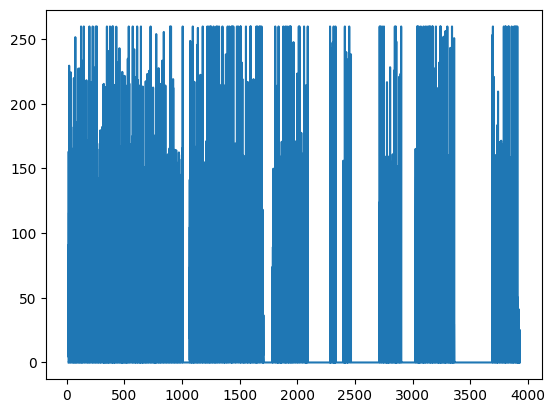

In [ ]:
values = nap_ds["speed_troughs"].values
import matplotlib.pyplot as plt
plt.plot(nap_ds["speed"].t, nap_ds["speed"].values)
plt.scatter(nap_ds["chan"]

TypeError: Cannot set the following metadata:
[{'attrs': {'type': 'changepoints', 'target_feature': 'speed', 'prominence': 0.3}}].
Metadata columns provided must be  of type `panda.Series`, `tuple`, `list`, or `numpy.ndarray`.

In [35]:
troughs[0]

Time (s)
17.132066667
17.182066667
17.207066667
17.247066667
17.277066667
17.327066667
17.357066667
...
3927.6978
3927.7378
3927.7778
3927.8178
3927.8578
3927.9078
3927.9578
shape: 23365

In [22]:
from scipy.signal import find_peaks

peaks = add_changepoints(data, func=lambda x, **kw: find_peaks(x, **kw)[0], name="peaks", height=0.5)
# angles = add_feature(pos, func=compute_angle, name="angle")
# rgb = add_feature(pos, func=compute_rgb, name="angle_rgb", output_columns=["R", "G", "B"])

In [24]:
path = r"C:\Users\aksel\.ethograph\example_data\Moll2025\Trial_data.nc"

import ethograph as eto

dt = eto.open(path)
dt

<xarray.DataTree>
Group: /
├── Group: /115
│       Dimensions:               (time: 1169, space: 3, keypoints: 3, individuals: 1,
│                                  s3d_dims: 20, RGB: 3, segment: 15)
│       Coordinates:
│         * time                  (time) float64 9kB 0.0 0.005 0.01 ... 5.83 5.835 5.84
│         * space                 (space) <U1 12B 'x' 'y' 'z'
│         * keypoints             (keypoints) <U8 96B 'beakTip' 'stickTip' 'pellet'
│         * individuals           (individuals) <U5 20B 'Crow1'
│       Dimensions without coordinates: s3d_dims, RGB, segment
│       Data variables: (12/18)
│           position              (time, space, keypoints, individuals) float64 84kB ...
│           confidence            (time, keypoints, individuals) float32 14kB ...
│           velocity              (time, space, keypoints, individuals) float64 84kB ...
│           speed                 (time, keypoints, individuals) float64 28kB ...
│           acceleration          (time, space, keypoints, individuals) float64 84kB ...
│           pellet_beakTip_dist   (time) float64 9kB ...
│           ...                    ...
│           angles                (keypoints, individuals, time) float64 28kB ...
│           angle_rgb             (keypoints, individuals, time, RGB) float64 84kB ...
│           onset_s               (segment) float64 120B ...
│           offset_s              (segment) float64 120B ...
│           labels                (segment) int32 60B ...
│           individual            (segment) <U5 300B ...
│       Attributes:
│           source_software:  DeepLabCut
│           ds_type:          poses
│           fps:              200.0
│           time_unit:        seconds
│           source_file:      C:/Users/aksel/Documents/Code/EthoGraph/data/Moll2025/2...
│           trial:            115
│           bird:             Crow1
│           session_date:     2024-12-17
│           pellet_position:  left
│           human_verified:   1
├── Group: /41
│       Dimensions:               (time: 1077, space: 3, keypoints: 3, individuals: 1,
│                                  s3d_dims: 20, RGB: 3, segment: 14)
│       Coordinates:
│         * time                  (time) float64 9kB 0.0 0.005 0.01 ... 5.37 5.375 5.38
│         * space                 (space) <U1 12B 'x' 'y' 'z'
│         * keypoints             (keypoints) <U8 96B 'beakTip' 'stickTip' 'pellet'
│         * individuals           (individuals) <U5 20B 'Crow1'
│       Dimensions without coordinates: s3d_dims, RGB, segment
│       Data variables: (12/18)
│           position              (time, space, keypoints, individuals) float64 78kB ...
│           confidence            (time, keypoints, individuals) float32 13kB ...
│           velocity              (time, space, keypoints, individuals) float64 78kB ...
│           speed                 (time, keypoints, individuals) float64 26kB ...
│           acceleration          (time, space, keypoints, individuals) float64 78kB ...
│           pellet_beakTip_dist   (time) float64 9kB ...
│           ...                    ...
│           angles                (keypoints, individuals, time) float64 26kB ...
│           angle_rgb             (keypoints, individuals, time, RGB) float64 78kB ...
│           onset_s               (segment) float64 112B ...
│           offset_s              (segment) float64 112B ...
│           labels                (segment) int32 56B ...
│           individual            (segment) <U5 280B ...
│       Attributes:
│           source_software:  DeepLabCut
│           ds_type:          poses
│           fps:              200.0
│           time_unit:        seconds
│           source_file:      C:/Users/aksel/Documents/Code/EthoGraph/data/Moll2025/2...
│           trial:            41
│           bird:             Crow1
│           session_date:     2024-12-18
│           pellet_position:  right
│           human_verified:   1
└── Group: /session
        Dimensions:  (trial: 2, camera

In [29]:
dt.itrial(0).speed_troughs

<xarray.DataArray 'speed_troughs' (keypoints: 3, individuals: 1, time: 1169)> Size: 4kB
array([[[0, 0, ..., 0, 0]],

       [[0, 0, ..., 0, 0]],

       [[0, 0, ..., 0, 0]]], shape=(3, 1, 1169), dtype=int8)
Coordinates:
  * keypoints    (keypoints) <U8 96B 'beakTip' 'stickTip' 'pellet'
  * individuals  (individuals) <U5 20B 'Crow1'
  * time         (time) float64 9kB 0.0 0.005 0.01 0.015 ... 5.83 5.835 5.84
Attributes:
    type:            changepoints
    target_feature:  speed

In [3]:
result = data.apply(lambda x: (x - x.mean()) / x.std())
result

AttributeError: Time series object does not have the attribute apply

In [12]:
tuning_curves = nap.compute_tuning_curves(
    data=units,
    features=position,
    feature_names=["X", "Y"],
    range=[(-50, 50), (-50, 50)],
    bins=40,
)

# optional smoothing of tuning curves
def gaussian_filter_nan(a, sigma):
    v = np.where(np.isnan(a), 0, a)
    w = gaussian_filter((~np.isnan(a)).astype(float), sigma)
    return gaussian_filter(v, sigma) / w
tuning_curves_smooth = tuning_curves.copy()
tuning_curves_smooth.values = gaussian_filter_nan(tuning_curves.values, sigma=(0, 2, 2))

# Setting some xarray.DataArray attributes, for beauty
tuning_curves_smooth.name = "firing rate"
tuning_curves_smooth.attrs["unit"] = "Hz"
tuning_curves_smooth.coords["X"].attrs["unit"] = "cm"
tuning_curves_smooth.coords["Y"].attrs["unit"] = "cm"
tuning_curves

<xarray.DataArray (unit: 6, X: 40, Y: 40)> Size: 77kB
array([[[ 2.94117647,  0.        ,         nan, ...,  0.        ,
          0.        ,  1.38888889],
        [ 4.54545455,  0.        ,  7.89473684, ...,         nan,
                 nan,  0.        ],
        [ 0.        ,  0.        ,         nan, ...,         nan,
                 nan,  0.        ],
        ...,
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.94339623],
        [ 0.        ,  4.16666667,  0.        , ...,  0.        ,
          0.        ,  2.7173913 ],
        [ 0.        ,  4.54545455,  0.        , ...,  4.54545455,
          0.90909091,  1.5625    ]],

       [[ 0.        ,  2.94117647,         nan, ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.52083333,  0.        , ...,         nan,
                 nan,  0.        ],
        [ 0.        ,  0.        ,         nan, ...,         nan,
                 nan,  0.        ],
...
        [ 0.        ,  0.        ,  8.33333333, ...,  7.44680851,
          5.        ,  3.4591195 ],
        [ 6.25      ,  0.        ,  0.92592593, ..., 12.06896552,
          3.48837209,  4.89130435],
        [ 0.        ,  0.        ,  0.        , ...,  9.09090909,
          4.54545455,  3.90625   ]],

       [[ 2.94117647,  0.        ,         nan, ...,  0.        ,
          0.        ,  2.77777778],
        [ 0.        ,  0.52083333,  0.        , ...,         nan,
                 nan,  0.        ],
        [ 0.        ,  0.        ,         nan, ...,         nan,
                 nan,  0.        ],
        ...,
        [ 0.        ,  0.        ,  0.        , ...,  5.31914894,
          5.        ,  1.88679245],
        [ 6.25      ,  0.        ,  8.33333333, ...,  0.        ,
          0.        ,  0.54347826],
        [ 9.52380952,  6.81818182,  3.84615385, ...,  7.57575758,
          9.09090909, 10.9375    ]]], shape=(6, 40, 40))
Coordinates:
  * unit     (unit) int64 48B 0 1 2 3 4 5
  * X        (X) float64 320B -48.75 -46.25 -43.75 -41.25 ... 43.75 46.25 48.75
  * Y        (Y) float64 320B -48.75 -46.25 -43.75 -41.25 ... 43.75 46.25 48.75
Attributes: (4)

In [5]:
type(data["trials"][0])

pynapple.core.interval_set.IntervalSet